In [1]:

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

In [2]:
X_test.shape

(10000, 32, 32, 3)

In [3]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [4]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [5]:
y_test = y_test.reshape(-1,)

In [6]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [7]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

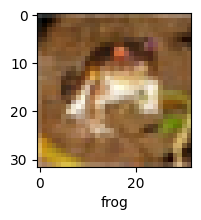

In [8]:
plot_sample(X_train, y_train, 0)

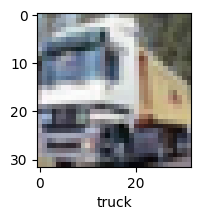

In [9]:
plot_sample(X_train, y_train, 1)

In [10]:
X_train = X_train / 255.0
X_test = X_test / 255.0
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.1),
])
print("X_train max:", X_train.max())

X_train max: 1.0


In [11]:
sample = X_train[0]
sample_batch = np.expand_dims(sample, 0)

In [12]:
augmented = data_augmentation(sample_batch)


In [13]:
print("X_train max:", X_train.max())

X_train max: 1.0


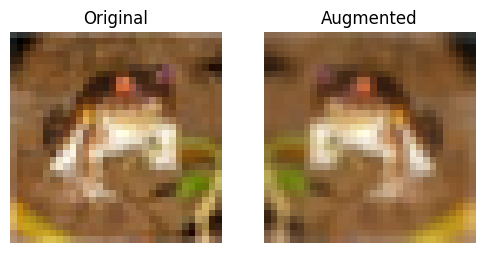

In [14]:
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
aug_img = np.clip(augmented[0].numpy(), 0, 1)
plt.imshow(aug_img)
plt.title("Augmented")
plt.axis('off')
plt.show()

In [15]:
print("Original sample:")
print("  dtype:", sample.dtype)
print("  min:", sample.min(), "max:", sample.max())

print("Augmented:")
print("  type:", type(augmented))
aug = augmented[0].numpy() if hasattr(augmented[0], 'numpy') else augmented[0]
print("  dtype:", aug.dtype)
print("  min:", aug.min(), "max:", aug.max())
print("  shape:", aug.shape)

Original sample:
  dtype: float64
  min: 0.0 max: 1.0
Augmented:
  type: <class 'tensorflow.python.framework.ops.EagerTensor'>
  dtype: float32
  min: 0.032507733 max: 0.9987501
  shape: (32, 32, 3)


In [16]:
print("X_train max:", X_train.max())
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train max: 1.0
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)


In [17]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 97ms/step - accuracy: 0.3209 - loss: 1.9437 - val_accuracy: 0.5149 - val_loss: 1.3708
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 97ms/step - accuracy: 0.4902 - loss: 1.4250 - val_accuracy: 0.5910 - val_loss: 1.1662
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 93ms/step - accuracy: 0.5718 - loss: 1.2224 - val_accuracy: 0.6299 - val_loss: 1.0898
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.6171 - loss: 1.0891 - val_accuracy: 0.6148 - val_loss: 1.1303
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 100ms/step - accuracy: 0.6494 - loss: 1.0037 - val_accuracy: 0.6923 - val_loss: 0.8898
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 108ms/step - accuracy: 0.6747 - loss: 0.9370 - val_accuracy: 0.7078 - val_loss: 0.8513
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 94ms/step - accuracy: 0.6951 - loss: 0.8857 - val_accuracy: 0.6964 - val_loss: 0.9012
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 95ms/step - accuracy: 0.7070 - loss: 0.8479 